In [ ]:
import numpy as np

cell_data = data[1:]
print(len(cell_data))
markers = ['DAPI', 'CD44', 'CD31', 'CD4', 'IFNG', 'CD20', 'PCNA', 'CD45RO', 'Pan-Cytokeratin', 'CD141', 'Beta-actin', 'Collagen4', 'CD14', 'SMA', 'CD11c', 'CD8', 'Vimentin', 'CD68', 'Ki67', 'EpCAM', 'IDO1', 'MPO', 'Podoplanin', 'HLA-DR', 'CD45']
morphology_list = ["Centroid X (pix)", "Centroid Y (pix)", "Nucleus: Area µm^2", "Nucleus: Circularity", "Nucleus: Solidity", "Cell: Area µm^2", "Cell: Circularity", "Cell: Solidity"]
cell_compartments = [": Nucleus: Mean", ": Cytoplasm: Mean", ": Membrane: Mean",": Cell: Mean"]
export_list = morphology_list
for m in markers:
    marker_components = ["".join([m, compartments]) for compartments in cell_compartments]
    for mc in marker_components:
        export_list.append(mc)
# export list will be columns in the output df
print(export_list)
# make empty table
num_cols = len(export_list)
num_rows = len(cell_data)
df = pd.DataFrame(index=range(num_rows), columns=range(num_cols))
df.columns = export_list
for i, cell in enumerate(cell_data):
    # Normalize measurement keys
    cell_measurements = {
        k.replace("Â", "").strip(): v for k, v in cell["properties"]["measurements"].items()
    }
    contour = np.array(cell["nucleusGeometry"]["coordinates"][0])
    cent_x = np.mean(contour[:, 0])
    cent_y = np.mean(contour[:, 1])
    cell_features = []  # this will be a row in the df (a cell and all of its features)
    for feature in export_list:
        try:
            if feature == "Centroid X (pix)":
                cell_features.append(round(cent_x, 2))
            elif feature == "Centroid Y (pix)":
                cell_features.append(round(cent_y, 2))
            else:
                cell_features.append(round(cell_measurements[feature], 2))
        except KeyError:
            cell_features.append(-1)  # will remove rows with -1 later
    df.loc[i] = cell_features
outpth = r'\\10.99.68.178\Saurabh\Andre_Cell2Class\dk_stardist\exp_mx_lrg_test.csv'
df.to_csv(outpth)

The filtered DataFrame contains 1023605 rows.


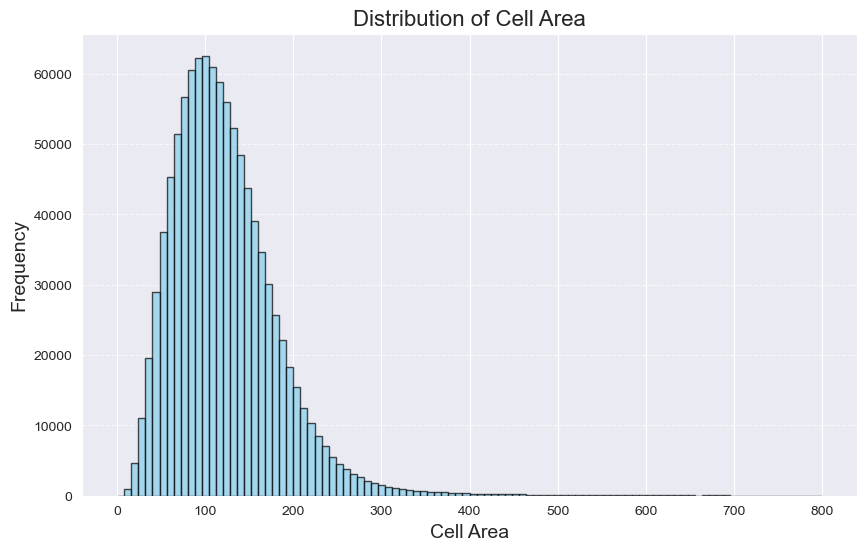

Original data size: 1023605
Cleaned data size: 999067


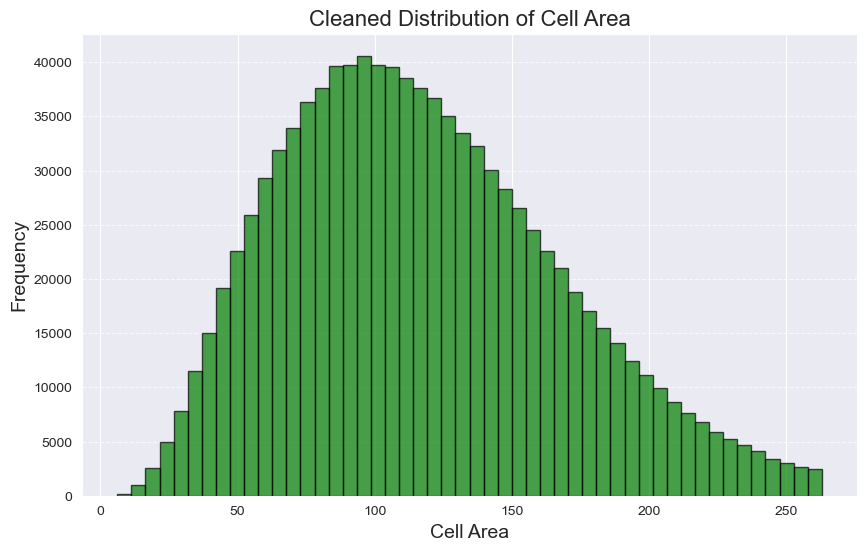

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the expression matrix CSV
data_path = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\dk_stardist\matricies\cell_means_mx_large.csv"
data = pd.read_csv(data_path)

# Filter based on centroid coordinates
filtered_data = data[
    (data['Centroid_x'] >= 1000) & (data['Centroid_x'] <= 33000) &
    (data['Centroid_y'] >= 700) & (data['Centroid_y'] <= 50000)
]

print(f"The filtered DataFrame contains {filtered_data.shape[0]} rows.")

# Plot the distribution of Cell_area
plt.figure(figsize=(10, 6))
plt.hist(filtered_data['Cell_area'], bins=100, range=(0, 800), color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Cell Area', fontsize=16)
plt.xlabel('Cell Area', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Remove outliers using the IQR method
Q1 = filtered_data['Cell_area'].quantile(0.25)  # First quartile
Q3 = filtered_data['Cell_area'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data to remove outliers
cleaned_data = filtered_data[(filtered_data['Cell_area'] >= lower_bound) & (filtered_data['Cell_area'] <= upper_bound)]

# Print summary before and after cleaning
print(f"Original data size: {filtered_data.shape[0]}")
print(f"Cleaned data size: {cleaned_data.shape[0]}")

# Plot the cleaned distribution
plt.figure(figsize=(10, 6))
plt.hist(cleaned_data['Cell_area'], bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Cleaned Distribution of Cell Area', fontsize=16)
plt.xlabel('Cell Area', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



In [2]:
# Drop non-marker columns (keep only marker intensities)
marker_data = cleaned_data.drop(columns=['Cell_index','Centroid_x', 'Centroid_y', 'Nucleus_area', 'Cell_area', 'DAPI', 'PCNA'])

# Convert to AnnData format
adata = sc.AnnData(marker_data)
adata.var_names = marker_data.columns  # Assign feature names

# Normalize expression values
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Scale the data
sc.pp.scale(adata, max_value = 5)
#adata.X = np.clip(adata.X, -2, 2)  # Clip values between -2 and 2

C:\Users\saura\.conda\envs\MAPS\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
print(adata.X.min(), adata.X.max())

-5.0 5.0


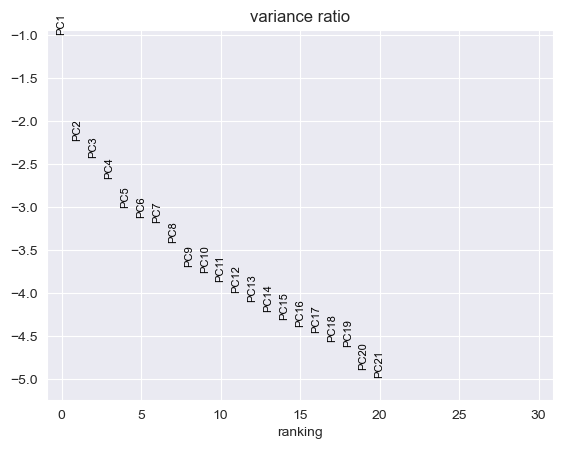

In [4]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, log=True)

In [21]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=11)  # Adjust PCs based on ElbowPlot

In [22]:
# Perform clustering
sc.tl.leiden(adata, resolution=0.75)  # You can also use `sc.tl.louvain`

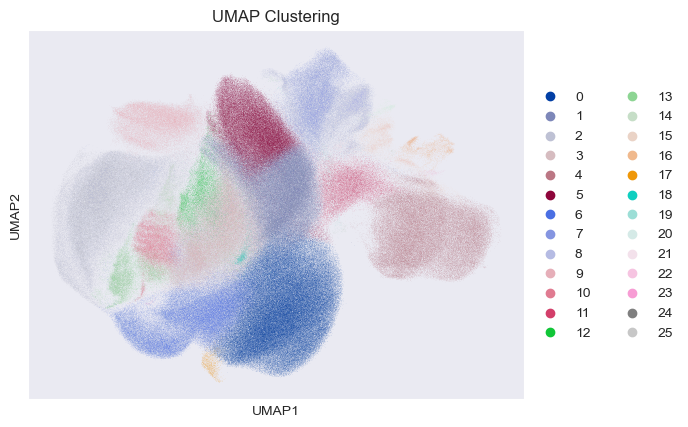

In [23]:
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden', title='UMAP Clustering')

C:\Users\saura\.conda\envs\MAPS\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\saura\.conda\envs\MAPS\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\saura\.conda\envs\MAPS\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\saura\.conda\envs\MAPS\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\saura\.conda\envs\MAPS\lib\site-packages\scanpy\tools\_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\saura\.conda\envs\MAP

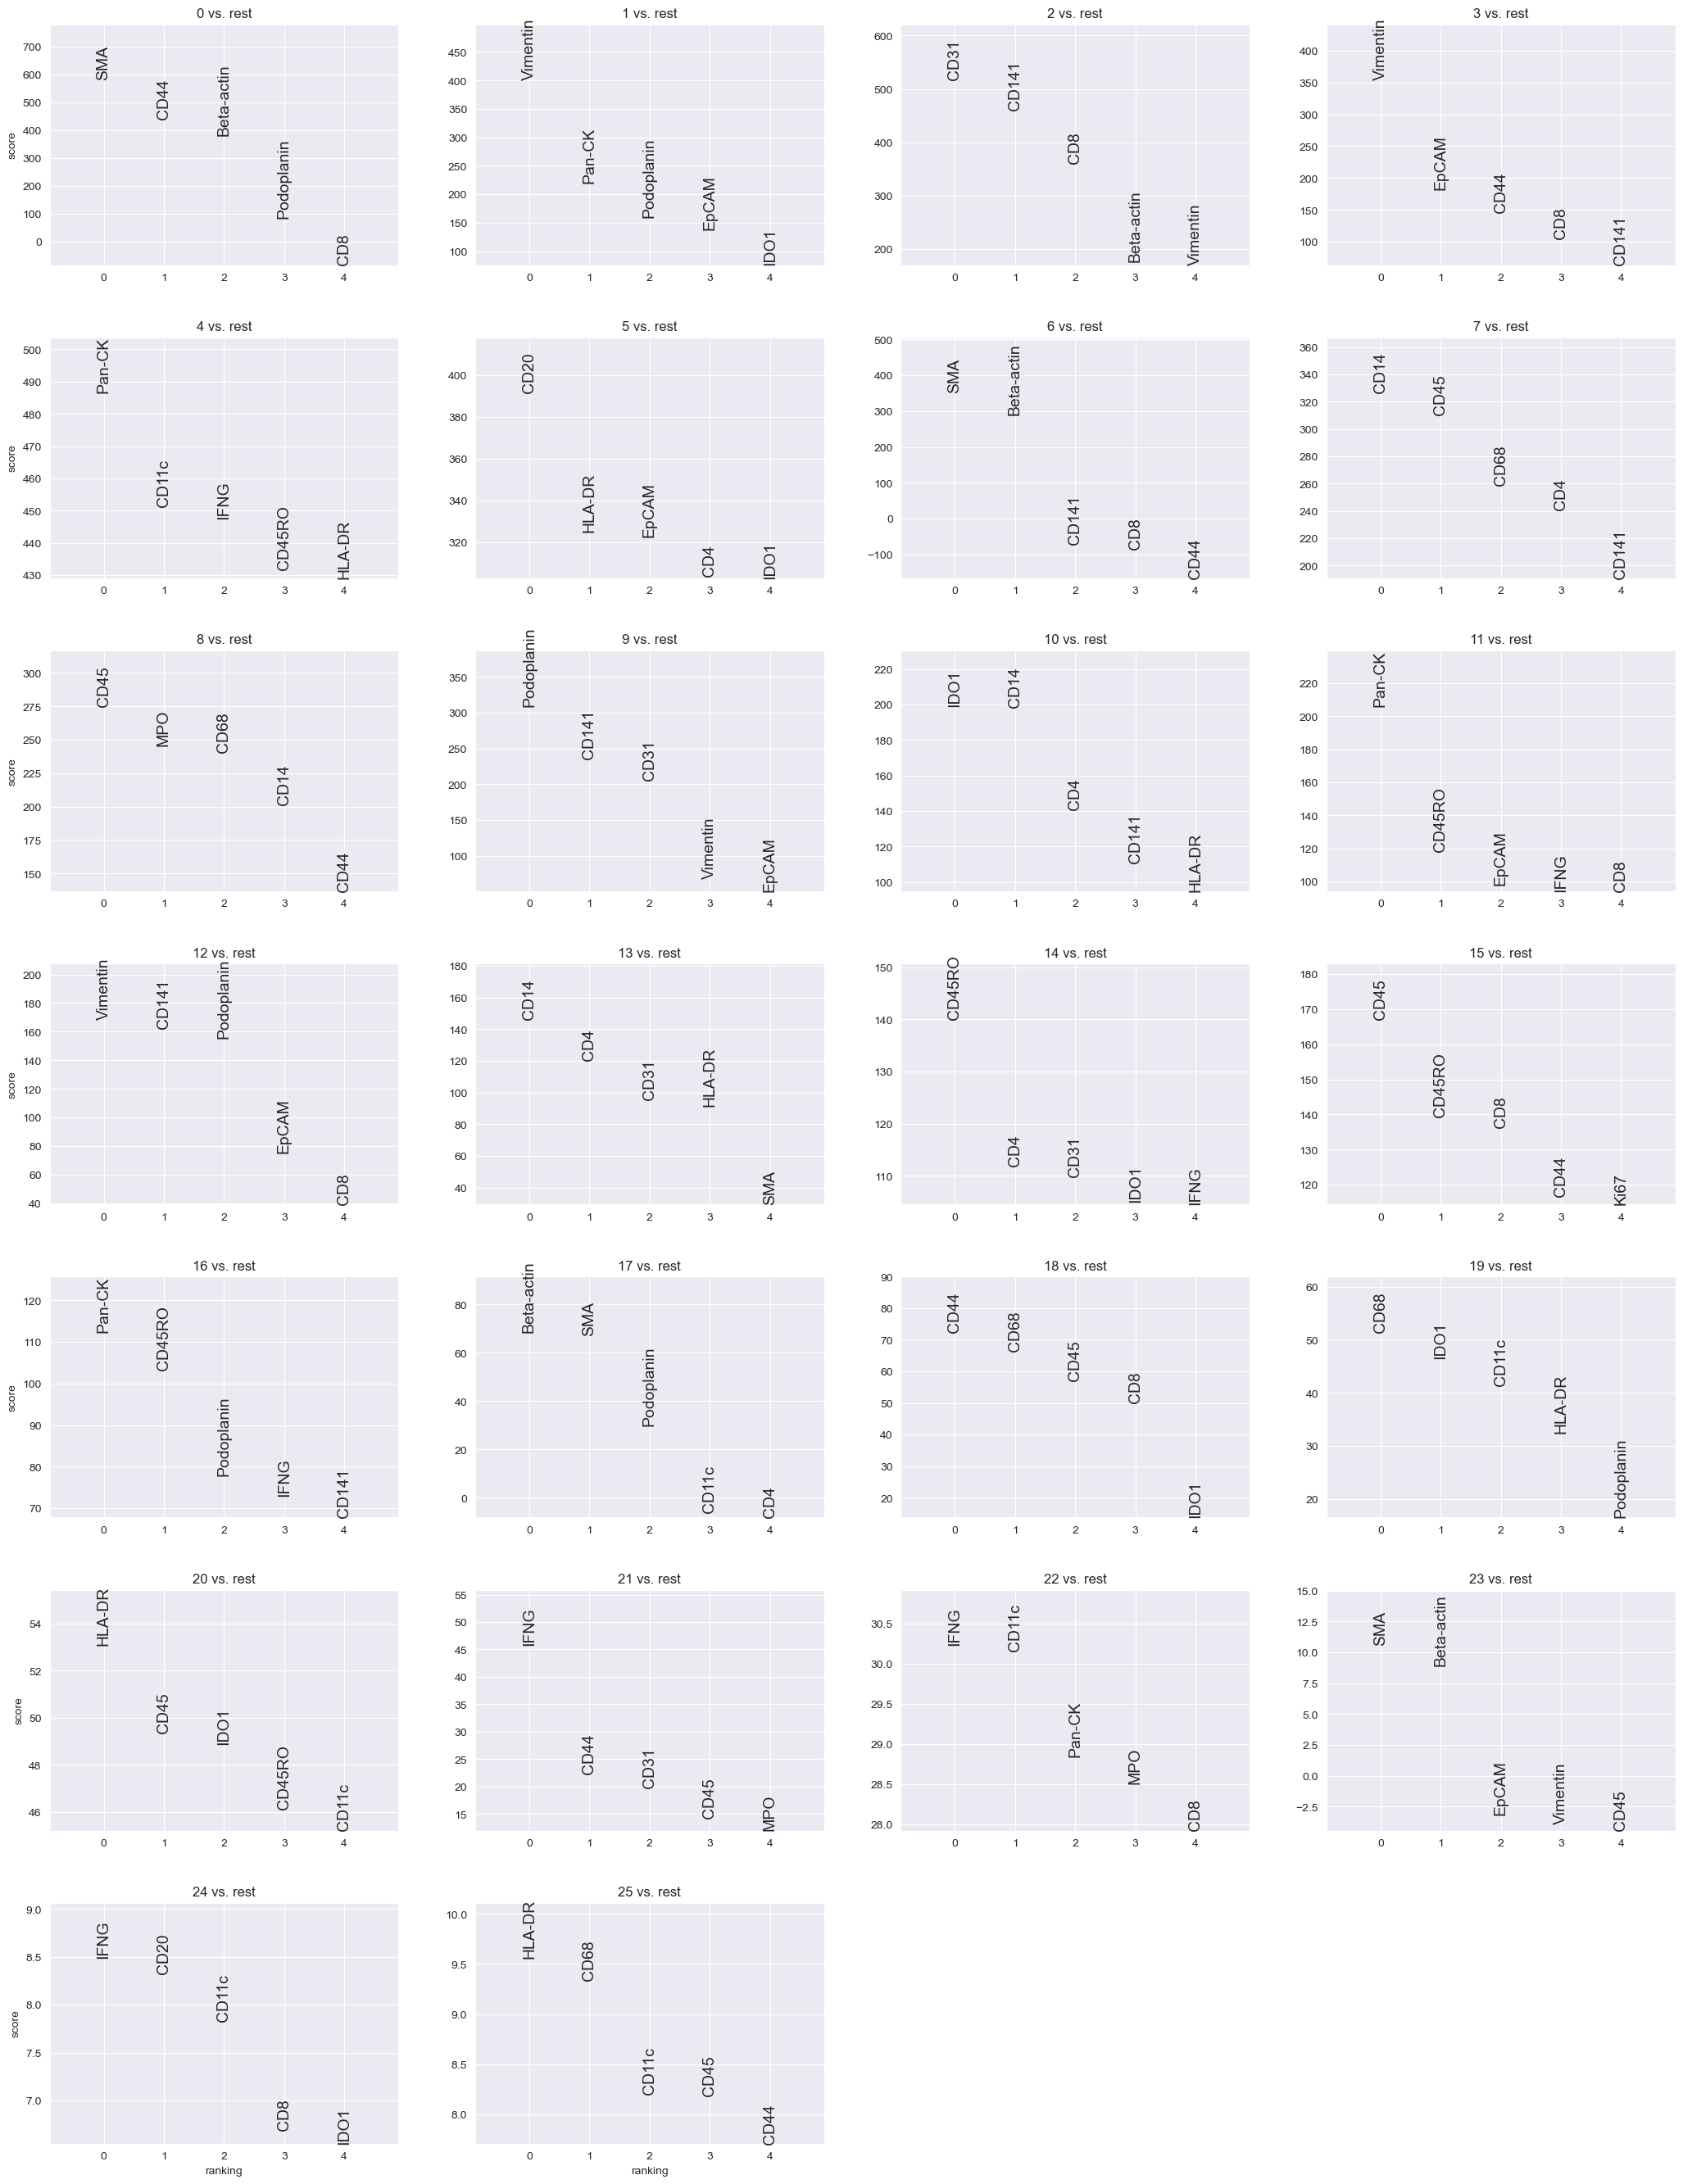

In [24]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False, fontsize=14)

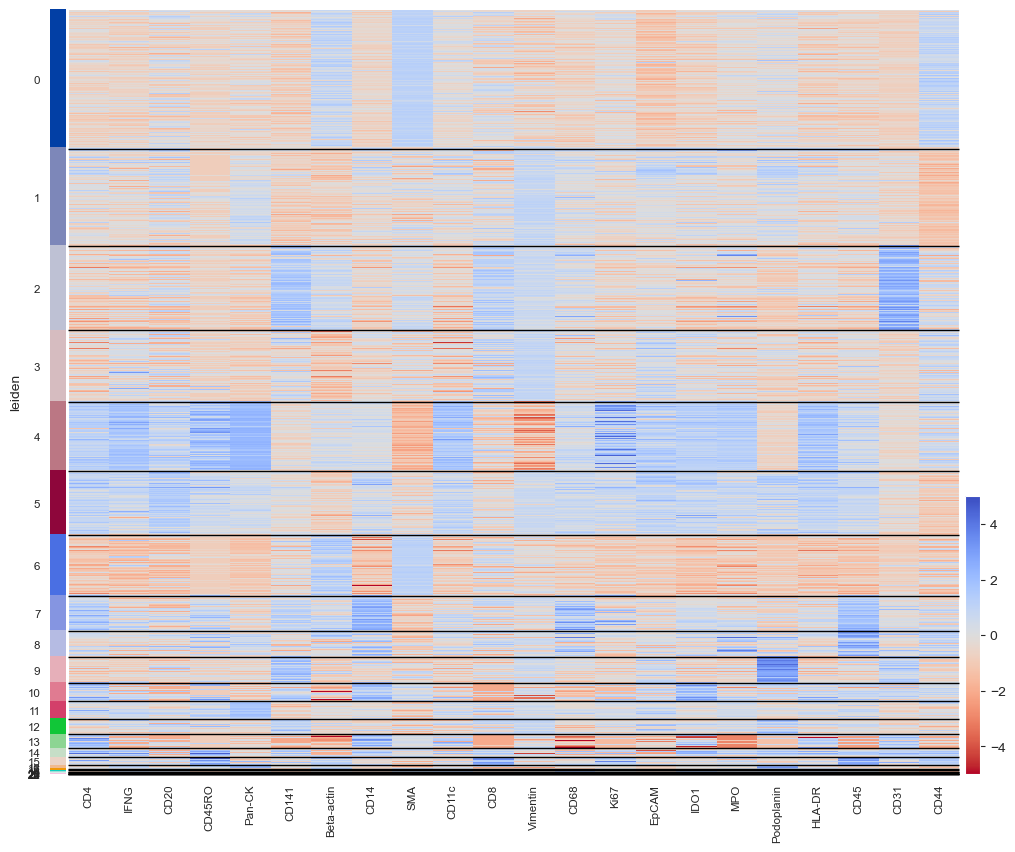

In [17]:
heatmap = sc.pl.heatmap(adata, var_names=adata.var_names[:24], groupby='leiden', cmap='coolwarm_r', figsize=(12, 10), show=False)


In [18]:
import os
import matplotlib.pyplot as plt

# Define original image dimensions
original_width = 35520
original_height = 53280

# Define the coordinate range to plot
x_min, x_max = 1000, 35520
y_min, y_max = 700, 53280

# Create a folder to save the combined cluster plot
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT"
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA"
output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA_res_0_75_pc11"
os.makedirs(output_folder, exist_ok=True)

# Assign the clusters from adata (if not already done)
cleaned_data['Cluster'] = adata.obs['leiden'].values

# Create a single figure to plot all clusters
fig = plt.figure(figsize=(original_width / 1000, original_height / 1000), dpi=800)  # Match figure size to image scale
ax = fig.add_subplot(1, 1, 1)

# Sort clusters to ensure the legend is ordered
unique_clusters = sorted(cleaned_data['Cluster'].unique(), key=lambda x: int(x))  # Ensure numerical sorting

# Initialize lists to store handles and labels for legend
handles = []
labels = []

# Iterate through each cluster and plot cells
for cluster in unique_clusters:
    # Subset data for the current cluster and within the coordinate range
    cluster_data = cleaned_data[
        (cleaned_data['Cluster'] == cluster) &
        (cleaned_data['Centroid_x'] >= x_min) & (cleaned_data['Centroid_x'] <= x_max) &
        (cleaned_data['Centroid_y'] >= y_min) & (cleaned_data['Centroid_y'] <= y_max)
    ]

    if not cluster_data.empty:  # Only plot if there are cells in the specified range
        # Plot the cells for the current cluster
        scatter = ax.scatter(
            cluster_data['Centroid_x'], cluster_data['Centroid_y'],
            s=cluster_data.get('cellSize', 0.5),  # Use 'cellSize' if available, otherwise default to 0.5
            label=f'Cluster {cluster}', alpha=1
        )
        handles.append(scatter)  # Save the plot handle
        labels.append(f'Cluster {cluster}')  # Save the corresponding label

# Set axis limits and orientation
plt.axis('off')  # Turn off axes for a clean overlay
plt.xlim(0, original_width)
plt.ylim(original_height, 0)  # Invert y-axis to match image orientation
plt.gca().set_aspect('equal', adjustable='box')

# Add an ordered legend with larger markers
legend = ax.legend(handles, labels, loc='upper right', fontsize=20, frameon=True, markerscale=10)

# Save the combined plot
output_path = os.path.join(output_folder, 'combined_clusters.png')
plt.savefig(output_path, dpi=800, bbox_inches='tight', pad_inches=0)
plt.close()

print(f"Combined cluster plot saved in the folder: {output_folder}")


C:\Users\saura\AppData\Local\Temp\ipykernel_2088\4030054267.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Cluster'] = adata.obs['leiden'].values


Combined cluster plot saved in the folder: \\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA_res_0_75


In [19]:
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered"
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA"
output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res_0_75_pc11"
# make the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)
cleaned_data['Cluster'] = adata.obs['leiden'].values
csv_output_path = os.path.join(output_folder, 'clustered_data.csv')
cleaned_data.to_csv(csv_output_path, index=False)

C:\Users\saura\AppData\Local\Temp\ipykernel_2088\1409013243.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Cluster'] = adata.obs['leiden'].values


In [20]:
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered"
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA"
output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res_0_75"
# Save the full AnnData object (.h5ad) for faster reloading
h5ad_output_path = os.path.join(output_folder, 'processed_clustered_data.h5ad')
adata.write(h5ad_output_path)

print(f"Clustered data saved as CSV at: {csv_output_path}")
print(f"Processed AnnData object saved at: {h5ad_output_path}")

Clustered data saved as CSV at: \\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res_0_75\clustered_data.csv
Processed AnnData object saved at: \\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res_0_75\processed_clustered_data.h5ad


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
csv_file = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res1\clustered_data.csv"  # Change to your actual file
df = pd.read_csv(csv_file)



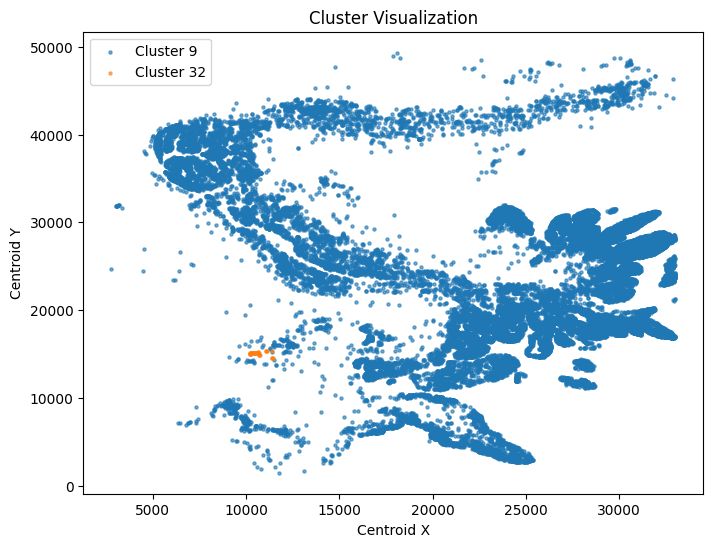

In [45]:

# Scatter plot of clusters
def plot_clusters(df, selected_clusters=None, title="Cluster Visualization"):
    plt.figure(figsize=(8, 6))

    if selected_clusters is None:
        selected_clusters = df["Cluster"].unique()  # Plot all clusters by default

    for cluster in selected_clusters:
        cluster_data = df[df["Cluster"] == cluster]
        plt.scatter(cluster_data["Centroid_x"], cluster_data["Centroid_y"], s=5, label=f"Cluster {cluster}", alpha=0.6)

    plt.xlabel("Centroid X")
    plt.ylabel("Centroid Y")
    plt.title(title)

    # plt.xlim(5000, 10000)  # Zoom in on x-axis from 5000 to 10000
    # plt.ylim(20000, 30000)  # Zoom in on y-axis from 20000 to 30000

    # plt.xlim(20000, 25000)  # Zoom in on x-axis from 5000 to 10000
    # plt.ylim(10000, 20000)  # Zoom in on y-axis from 20000 to 30000

    # plt.xlim(10000, 15000)  # Zoom in on x-axis from 5000 to 10000
    # plt.ylim(10000, 20000)  # Zoom in on y-axis from 20000 to 30000

    plt.legend()
    plt.show()

# Specify clusters to plot (set to None to plot all)
#selected_clusters = [0,6,24,31]  # myofibroblast
selected_clusters = [9,32]  # Change this to the cluster numbers you want to visualize
plot_clusters(df, selected_clusters)

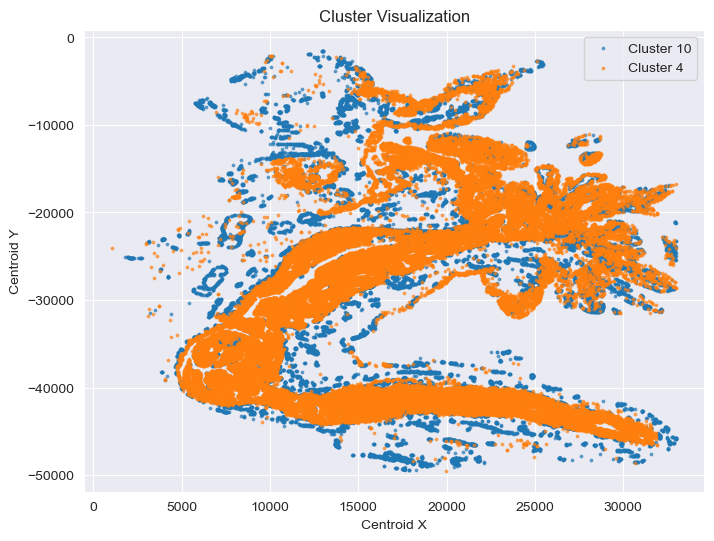

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
csv_file = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res1\clustered_data.csv"  # Change to your actual file
df = pd.read_csv(csv_file)
x_min, x_max = 20000, 30000
y_min, y_max = 5000, 10000
# Scatter plot of clusters
def plot_clusters(df, selected_clusters=None, title="Cluster Visualization"):
    plt.figure(figsize=(8, 6))

    if selected_clusters is None:
        selected_clusters = df["Cluster"].unique()  # Plot all clusters by default

    # for cluster in unique_clusters:
    #     # Subset data for the current cluster and within the coordinate range
    #     cluster_data = df[
    #         (df['Cluster'] == cluster) &
    #         (df['Centroid_x'] >= x_min) & (df['Centroid_x'] <= x_max) &
    #         (df['Centroid_y'] >= y_min) & (df['Centroid_y'] <= y_max)
    #     ]
    #     plt.scatter(cluster_data["Centroid_x"], cluster_data["Centroid_y"], s=3, label=f"Cluster {cluster}", alpha=0.6)

    for cluster in selected_clusters:
        cluster_data = df[df["Cluster"] == cluster]
        # plt.scatter(cluster_data["Centroid_x"], cluster_data["Centroid_y"], s=5, label=f"Cluster {cluster}", alpha=0.6)
        plt.scatter(cluster_data["Centroid_x"], -cluster_data["Centroid_y"], s=3, label=f"Cluster {cluster}", alpha=0.6)

    plt.xlabel("Centroid X")
    plt.ylabel("Centroid Y")
    plt.title(title)
    plt.legend()
    plt.show()

# Specify clusters to plot (set to None to plot all)
#selected_clusters = [0,6,24,31]  # myofibroblast
selected_clusters = [10,4]  # Change this to the cluster numbers you want to visualize
plot_clusters(df, selected_clusters)

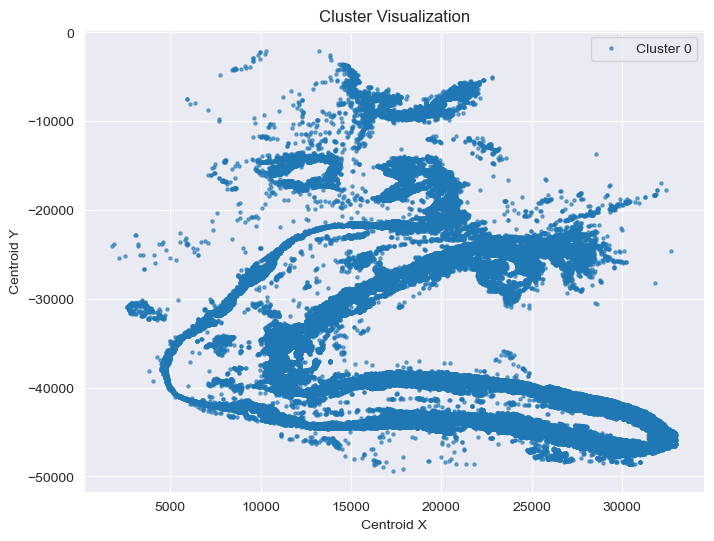

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
csv_file = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res1\clustered_data.csv"  # Change to your actual file
df = pd.read_csv(csv_file)

x_min, x_max = 1000, 35520
y_min, y_max = 700, 53280

# Scatter plot of clusters
def plot_clusters(df, selected_clusters=None, title="Cluster Visualization"):
    plt.figure(figsize=(8, 6))

    if selected_clusters is None:
        selected_clusters = df["Cluster"].unique()  # Plot all clusters by default

    for cluster in selected_clusters:
        cluster_data = df[df["Cluster"] == cluster]
        plt.scatter(cluster_data["Centroid_x"], -cluster_data["Centroid_y"], s=5, label=f"Cluster {cluster}", alpha=0.6)

    plt.xlabel("Centroid X")
    plt.ylabel("Centroid Y")
    plt.title(title)
    plt.legend()
    plt.show()

# Specify clusters to plot (set to None to plot all)
#selected_clusters = [0,6,24,31]  # myofibroblast
selected_clusters = [0]  # Change this to the cluster numbers you want to visualize
plot_clusters(df, selected_clusters)

In [ ]:
# Merge clusters interactively
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
csv_file = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res1\clustered_data.csv"  # Change to your actual file
df = pd.read_csv(csv_file)

# Scatter plot of clusters
def plot_clusters(df, selected_clusters=None, title="Cluster Visualization"):
    plt.figure(figsize=(8, 6))

    if selected_clusters is None:
        selected_clusters = df["Cluster"].unique()  # Plot all clusters by default

    for cluster in selected_clusters:
        cluster_data = df[df["Cluster"] == cluster]
        plt.scatter(cluster_data["Centroid_x"], cluster_data["Centroid_y"], s=5, label=f"Cluster {cluster}", alpha=0.6)

    plt.xlabel("Centroid X")
    plt.ylabel("Centroid Y")
    plt.title(title)
    plt.legend()
    plt.show()

# Specify clusters to plot (set to None to plot all)
#selected_clusters = [0,6,24,31]  # myofibroblast
selected_clusters = [3,15,10]  # Change this to the cluster numbers you want to visualize
plot_clusters(df, selected_clusters)

def merge_clusters(df, merge_map):
    """
    merge_map: Dictionary mapping old cluster labels to new ones.
               Example: {3: 1, 5: 2} merges cluster 3 into 1 and 5 into 2.
    """
    df["Cluster"] = df["Cluster"].replace(merge_map)
    return df

# Example: Merge clusters 3 and 5 into 1
merge_map = {3: 1, 5: 1}  # Change this mapping as needed
df = merge_clusters(df, merge_map)

# Plot after merging
plot_clusters(df, title="After Merging Clusters")

# Save updated CSV
df.to_csv("updated_clusters.csv", index=False)
print("Updated CSV saved as 'updated_clusters.csv'.")

import os
import matplotlib.pyplot as plt

# Define original image dimensions
original_width = 35520
original_height = 53280

# Define the coordinate range to plot
x_min, x_max = 1000, 35520
y_min, y_max = 700, 53280

# Create a folder to save the combined cluster plot
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT"
# output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA"
output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA_res_0_75_pc11"
os.makedirs(output_folder, exist_ok=True)

# Assign the clusters from adata (if not already done)
cleaned_data['Cluster'] = adata.obs['leiden'].values

# Create a single figure to plot all clusters
fig = plt.figure(figsize=(original_width / 1000, original_height / 1000), dpi=800)  # Match figure size to image scale
ax = fig.add_subplot(1, 1, 1)

# Sort clusters to ensure the legend is ordered
unique_clusters = sorted(cleaned_data['Cluster'].unique(), key=lambda x: int(x))  # Ensure numerical sorting

# Initialize lists to store handles and labels for legend
handles = []
labels = []

# Iterate through each cluster and plot cells
for cluster in unique_clusters:
    # Subset data for the current cluster and within the coordinate range
    cluster_data = cleaned_data[
        (cleaned_data['Cluster'] == cluster) &
        (cleaned_data['Centroid_x'] >= x_min) & (cleaned_data['Centroid_x'] <= x_max) &
        (cleaned_data['Centroid_y'] >= y_min) & (cleaned_data['Centroid_y'] <= y_max)
    ]

    if not cluster_data.empty:  # Only plot if there are cells in the specified range
        # Plot the cells for the current cluster
        scatter = ax.scatter(
            cluster_data['Centroid_x'], cluster_data['Centroid_y'],
            s=cluster_data.get('cellSize', 0.5),  # Use 'cellSize' if available, otherwise default to 0.5
            label=f'Cluster {cluster}', alpha=1
        )
        handles.append(scatter)  # Save the plot handle
        labels.append(f'Cluster {cluster}')  # Save the corresponding label

# Set axis limits and orientation
plt.axis('off')  # Turn off axes for a clean overlay
plt.xlim(0, original_width)
plt.ylim(original_height, 0)  # Invert y-axis to match image orientation
plt.gca().set_aspect('equal', adjustable='box')

# Add an ordered legend with larger markers
legend = ax.legend(handles, labels, loc='upper right', fontsize=20, frameon=True, markerscale=10)

# Save the combined plot
output_path = os.path.join(output_folder, 'combined_clusters.png')
plt.savefig(output_path, dpi=800, bbox_inches='tight', pad_inches=0)
plt.close()

print(f"Combined cluster plot saved in the folder: {output_folder}")



In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Define original image dimensions
original_width = 35520
original_height = 53280

# Define the coordinate range to plot
x_min, x_max = 1000, 35520
y_min, y_max = 700, 53280

# Output folder for saving the combined cluster plot
output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA_res_1_fx_cl_v3_FINALv2"
os.makedirs(output_folder, exist_ok=True)

# Load the CSV with updated cluster labels
csv_file = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\matrix_clustered_no_PCNA_res1\clustered_data.csv"
df = pd.read_csv(csv_file)

# Define cluster merging based on your mapping
# merge_map = {
#     **dict.fromkeys([0, 6, 14, 24, 31], "Myofibroblasts"),
#     **dict.fromkeys([1, 4, 18, 29], "Fibroblasts / Mesenchymal Cells"),
#     **dict.fromkeys([3, 10, 15], "Endothelial Cells"),
#     **dict.fromkeys([4, 23], "Epithelial Cells"),
#     **dict.fromkeys([7, 11, 17, 22, 26, 27, 33], "Macrophages / Monocytes"),
#     **dict.fromkeys([8, 28], "Activated T Cells (CD44⁺, IFNG⁺)"),
#     **dict.fromkeys([9], "CD4⁺ Helper T Cells"),
#     **dict.fromkeys([19, 25], "CD8⁺ Cytotoxic T Cells"),
#     **dict.fromkeys([30, 32], "Activated CD8⁺ T Cells (IFNG⁺, CD8⁺)"),
#     **dict.fromkeys([2, 9, 13, 20, 21, 32], "B Cells"),
#     **dict.fromkeys([5, 17, 26, 27, 30, 33], "Dendritic Cells"),
#     **dict.fromkeys([12, 16], "Proliferating Cells (Ki67⁺)")
# }
# merge_map = {
#     **dict.fromkeys([6, 14], "Myofibroblasts"),
#     **dict.fromkeys([4, 18], "Fibroblasts / Mesenchymal Cells"),
#     **dict.fromkeys([0, 24, 31], "Smooth muscle Cells"),
#     **dict.fromkeys([2, 8, 32, 9], "B Cells"),
#     **dict.fromkeys([26, 27, 33], "Regulatory Dendritic Cells (DCs)"),
#     **dict.fromkeys([21], "suppressed dendritic"),
#     **dict.fromkeys([1,13], "Dendritic Cells"),
#     **dict.fromkeys([19], "CD8 memory cytotoxic T cell"),
#     **dict.fromkeys([28], "Activated T Cells"),
#     **dict.fromkeys([29], "CD8+ T cells"),
#     **dict.fromkeys([20], "CD4 memory helper T cell"),
#     **dict.fromkeys([12], "Proliferating Cells (Ki67)"),
#     **dict.fromkeys([ 16, 32,30,5], "Epithelial Cells"),
#     **dict.fromkeys([15, 3, 23, 10], "Endothelial Cells"),
#     **dict.fromkeys([22], "Neutrophils"),
#     **dict.fromkeys([25], "Tumor-Associated Macrophages"),
#     **dict.fromkeys([7, 11, 17], "Macrophages /Monocytes")
# }

merge_map = {
    **dict.fromkeys([6,8, 14], "Myofibroblasts"),
    **dict.fromkeys([4, 18], "Fibroblasts / Mesenchymal Cells"),
    **dict.fromkeys([0, 24, 31], "Smooth muscle Cells"),
    **dict.fromkeys([2], "B Cells"),
    **dict.fromkeys([26, 27, 33], "Regulatory Dendritic Cells (DCs)"),
    **dict.fromkeys([21], "suppressed dendritic"),
    **dict.fromkeys([1,13,32], "Dendritic Cells"),
    **dict.fromkeys([19], "CD8 memory cytotoxic T cell"),
    **dict.fromkeys([28], "Activated T Cells"),
    **dict.fromkeys([29], "CD8+ T cells"),
    **dict.fromkeys([20], "CD4 memory helper T cell"),
    **dict.fromkeys([12], "Proliferating Cells (Ki67)"),
    **dict.fromkeys([ 16, 32,30,5], "Epithelial Cells"),
    **dict.fromkeys([15, 3, 23, 10], "Endothelial Cells"),
    **dict.fromkeys([22], "Neutrophils"),
    **dict.fromkeys([25], "Tumor-Associated Macrophages"),
    **dict.fromkeys([7, 11, 17], "Macrophages /Monocytes"),
    **dict.fromkeys([9], "Antigen-Presenting Cells (APCs)")
}
# Apply cluster merging
df["Cluster"] = df["Cluster"].replace(merge_map)

# Create figure to match image scale
fig = plt.figure(figsize=(original_width / 1000, original_height / 1000), dpi=800)
ax = fig.add_subplot(1, 1, 1)

# Sort and get unique cluster names
unique_clusters = sorted(df["Cluster"].unique())

# Initialize lists for legend
handles = []
labels = []

# Plot each merged cluster
for cluster in unique_clusters:
    cluster_data = df[
        (df["Cluster"] == cluster) &
        (df["Centroid_x"] >= x_min) & (df["Centroid_x"] <= x_max) &
        (df["Centroid_y"] >= y_min) & (df["Centroid_y"] <= y_max)
    ]

    if not cluster_data.empty:
        scatter = ax.scatter(
            cluster_data["Centroid_x"], cluster_data["Centroid_y"],
            s=0.5, label=cluster, alpha=1
        )
        handles.append(scatter)
        labels.append(cluster)

# Remove axes and set limits
plt.axis("off")
plt.xlim(0, original_width)
plt.ylim(original_height, 0)  # Invert y-axis

# Add legend
ax.legend(handles, labels, loc="upper right", fontsize=20, frameon=True, markerscale=10)

# Save image
output_image = os.path.join(output_folder, "combined_clusters.png")
plt.savefig(output_image, dpi=800, bbox_inches="tight", pad_inches=0)
plt.close()

print(f"Combined cluster plot saved at {output_image}")


Combined cluster plot saved at \\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA_res_1_fx_cl_v3_FINALv2\combined_clusters.png


In [47]:
df.head(4)

,Cell_index,Centroid_x,Centroid_y,Nucleus_area,Cell_area,DAPI,CD4,IFNG,CD20,PCNA,...,Ki67,EpCAM,IDO1,MPO,Podoplanin,HLA-DR,CD45,CD31,CD44,Cluster
0,1,12961.43,1232.98,36.31,223.03,1.16,0.12,0.01,0.00,1.32,...,0.00,0.04,0.10,0.01,0.01,0.03,0.01,0.0,0.01,Dendritic Cells
1,2,12908.08,1251.93,49.72,252.02,4.88,1.44,0.98,0.08,12.00,...,0.06,4.20,1.56,0.69,1.24,0.35,0.14,0.0,3.47,Fibroblasts / Mesenchymal Cells
2,3,12959.36,1268.01,16.16,140.18,2.84,1.55,1.87,0.03,12.44,...,0.04,2.68,1.26,0.41,2.17,0.34,0.17,0.0,1.98,Fibroblasts / Mesenchymal Cells
3,4,12939.29,1275.33,9.79,92.61,3.21,1.68,3.09,0.03,14.65,...,0.04,3.95,1.69,0.32,5.34,0.23,0.07,0.0,5.09,Fibroblasts / Mesenchymal Cells


In [48]:
output_folder

'\\\\10.99.68.178\\Saurabh\\Andre_Cell2Class\\combined_cluster_plot_wholeFT_no_PCNA_res_1_fx_cl_v3_FINALv2'

In [49]:
csv_output_path = os.path.join(output_folder, 'clustered_data_cell_phenotypes.csv')
df.to_csv(csv_output_path, index=False)

In [25]:
#old
import os
import matplotlib.pyplot as plt

# Define original image dimensions (you can adjust these values)
original_width = 53280
original_height = 35520

# Define the coordinate range you want to plot
x_min, x_max = 1000, 33000
# y_min, y_max = 17000, 23000
y_min, y_max = 700, 25000

# Create a folder to save the combined cluster plot
output_folder = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_halfFT"
os.makedirs(output_folder, exist_ok=True)

# Assuming cleaned_data already contains 'Cluster' and centroid_x, centroid_y
# Assign the clusters from adata (if not already done)
cleaned_data['Cluster'] = adata.obs['leiden'].values

# Create a single figure to plot all clusters
plt.figure(figsize=(original_width / 1000, original_height / 1000), dpi=100)  # Match figure size to image scale

# Iterate through each cluster and plot cells
unique_clusters = cleaned_data['Cluster'].unique()

for cluster in unique_clusters:
    # Subset data for the current cluster and within the coordinate range
    cluster_data = cleaned_data[
        (cleaned_data['Cluster'] == cluster) &
        (cleaned_data['Centroid_x'] >= x_min) & (cleaned_data['Centroid_x'] <= x_max) &
        (cleaned_data['Centroid_y'] >= y_min) & (cleaned_data['Centroid_y'] <= y_max)
    ]

    if not cluster_data.empty:  # Only plot if there are cells in the specified range
        # Plot the cells for the current cluster
        plt.scatter(
            cluster_data['Centroid_x'], cluster_data['Centroid_y'],
            s=cluster_data.get('cellSize', 4),  # Use 'cellSize' if available, otherwise default to 10
            label=f'Cluster {cluster}', alpha=0.6
        )

# Set the title and axis limits
plt.title('All Clusters', fontsize=16)
plt.axis('off')  # Turn off axes for direct overlay compatibility
plt.xlim(0, original_width)  # Set x-axis range to match the image dimensions
plt.ylim(original_height, 0)  # Set y-axis range (inverted for image orientation)
plt.gca().set_aspect('equal', adjustable='box')  # Ensure equal scaling

# Add legend to distinguish clusters
plt.legend(loc='upper right')

# Save the combined plot
output_path = os.path.join(output_folder, 'combined_clusters.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

print(f"Combined cluster plot saved in the folder: {output_folder}")


C:\Users\saura\AppData\Local\Temp\ipykernel_2088\2059172178.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Cluster'] = adata.obs['leiden'].values

KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x000001ECDC35DEE0> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



Error in callback <function flush_figures at 0x000001EC8000C310> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



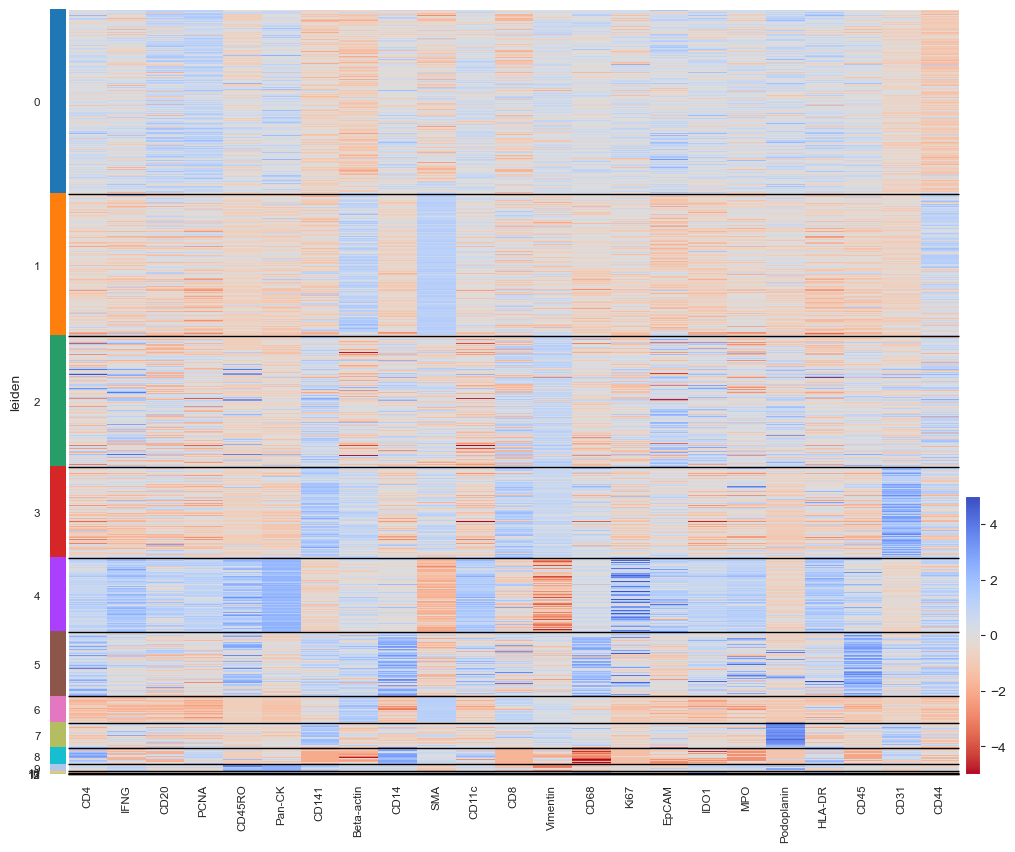

In [12]:
heatmap = sc.pl.heatmap(adata, var_names=adata.var_names[:24], groupby='leiden', cmap='coolwarm_r', figsize=(12, 10), show=False)


In [1]:
import pandas as pd
import scanpy as sc
import squidpy as sm
import seaborn as sns

# Load CSV
file_path = r"\\10.99.68.178\Saurabh\Andre_Cell2Class\combined_cluster_plot_wholeFT_no_PCNA_res_1_fx_cl_v3_FINALv2\normalized_expression_matrix.csv"
df = pd.read_csv(file_path)

C:\Users\Andre\AppData\Roaming\Python\Python39\site-packages\numba\core\decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
# Extract marker expressions (Columns 5-26) and phenotype (Column 27)
markers = df.iloc[:, 4:26]  # Gene expression data
phenotypes = df.iloc[:, 26].astype(str)  # Convert to string for categorical data
adata = sc.AnnData(markers)
adata.obs['phenotype'] = phenotypes.values
adata.var_names = df.columns[4:26]  # Set gene names

C:\Users\Andre\.conda\envs\CODA_HE_nucleus_segmentation\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
sc.pp.neighbors(adata)

In [4]:
# Compute UMAP
sc.tl.umap(adata)

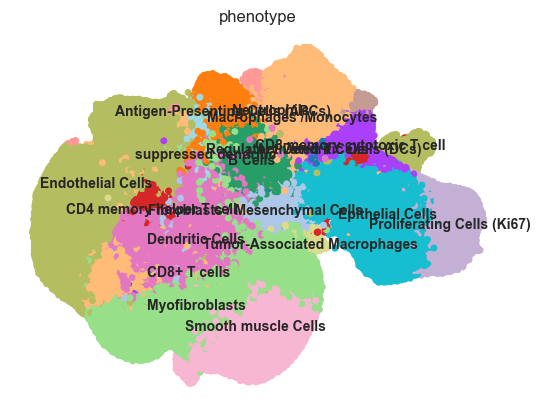

In [5]:
# Plot UMAP with phenotype labels
sc.pl.umap(adata, color=['phenotype'], legend_loc='on data', frameon=False, s=100)